# Lab 05: Renewable Energy Prediction with Random Forest

Necessary imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Data Loading

In [ ]:
url = "https://github.com/masterfloss/data/raw/refs/heads/main/WBESG6123.xlsx"
df = pd.read_excel(url)

In [ ]:
df.head()

,Unnamed: 0,INDICATOR_LABEL,FREQ_LABEL,TIME_PERIOD,REF_AREA_LABEL,OBS_VALUE,UNIT_TYPE_LABEL
0,0,Agricultural land (% of land area),Annual,1961,Afghanistan,57.878356,Ratio
1,1,Agricultural land (% of land area),Annual,1961,Angola,36.237266,Ratio
2,2,Agricultural land (% of land area),Annual,1961,Albania,44.963504,Ratio
3,3,Agricultural land (% of land area),Annual,1961,Andorra,55.319149,Ratio
4,4,Agricultural land (% of land area),Annual,1961,Arab World,27.845967,Ratio


## Task 2: Data Processing

In [ ]:
# 1. Rename columns
df = df.rename(columns={
    'REF_AREA_LABEL': 'country',
    'TIME_PERIOD': 'year',
    'INDICATOR_LABEL': 'indicator',
    'OBS_VALUE': 'value'
})

# 2. Keep only specific columns
df = df[['country', 'year', 'indicator', 'value']]

In [ ]:
df.head()

,country,year,indicator,value
0,Afghanistan,1961,Agricultural land (% of land area),57.878356
1,Angola,1961,Agricultural land (% of land area),36.237266
2,Albania,1961,Agricultural land (% of land area),44.963504
3,Andorra,1961,Agricultural land (% of land area),55.319149
4,Arab World,1961,Agricultural land (% of land area),27.845967


In [ ]:
# 3. Convert from long to wide format using pivot_table
# Using index=[country, year], columns=indicator, values=value
df_wide = df.pivot_table(
    index=['country', 'year'],
    columns='indicator',
    values='value').reset_index()

In [ ]:
df_wide.head()

indicator,country,year,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: net forest depletion (% of GNI),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)","Annual freshwater withdrawals, total (% of internal resources)","Annualized average growth rate in per capita real survey mean consumption or income, total population (%)",...,"School enrollment, primary (% gross)","School enrollment, primary and secondary (gross), gender parity index (GPI)",Scientific and technical journal articles,Standardised Precipitation-Evapotranspiration Index,Strength of legal rights index (0=weak to 12=strong),Terrestrial and marine protected areas (% of total territorial area),Tree Cover Loss (hectares),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Unmet need for contraception (% of married women ages 15-49),Voice and Accountability: Estimate
0,Afghanistan,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.761520,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1961,NaN,NaN,NaN,NaN,57.878356,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.076736,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1962,NaN,NaN,NaN,NaN,57.955016,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.665528,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1963,NaN,NaN,NaN,NaN,58.031676,NaN,NaN,NaN,...,NaN,NaN,NaN,0.216942,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1964,NaN,NaN,NaN,NaN,58.116002,NaN,NaN,NaN,...,NaN,NaN,NaN,0.488956,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 4. Define the target variable
target_col = "Renewable electricity output (% of total electricity output)"

# 5. Separate predictors (X) and target (y) [cite: 35]
y = df_wide[target_col]
# Drop the target and the non-numeric index columns to form predictors
X = df_wide.drop(columns=['country', 'year', target_col])

## Task 3: Feature selection
- Correlation matrix
- Avoid multicollinearity

In [ ]:
# Compute correlation matrix of predictors
corr_matrix = X.corr().abs()

# Remove correlated predictors (corr > 0.9) to avoid multicollinearity
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
X = X.drop(columns=to_drop)

# Check the number of features remaining
num_features_left = X.shape[1]
num_rows_left = X.shape[0]

print(f"Number of highly correlated features removed: {len(to_drop)}")
print(f"Number of features remaining: {num_features_left}")
print(f"Current dimensions of X (rows, columns): {X.shape}")

Number of highly correlated features removed: 9
Number of features remaining: 61
Current dimensions of X (rows, columns): (15296, 61)


Sanity check on multicollinearity: should have no bright red spots

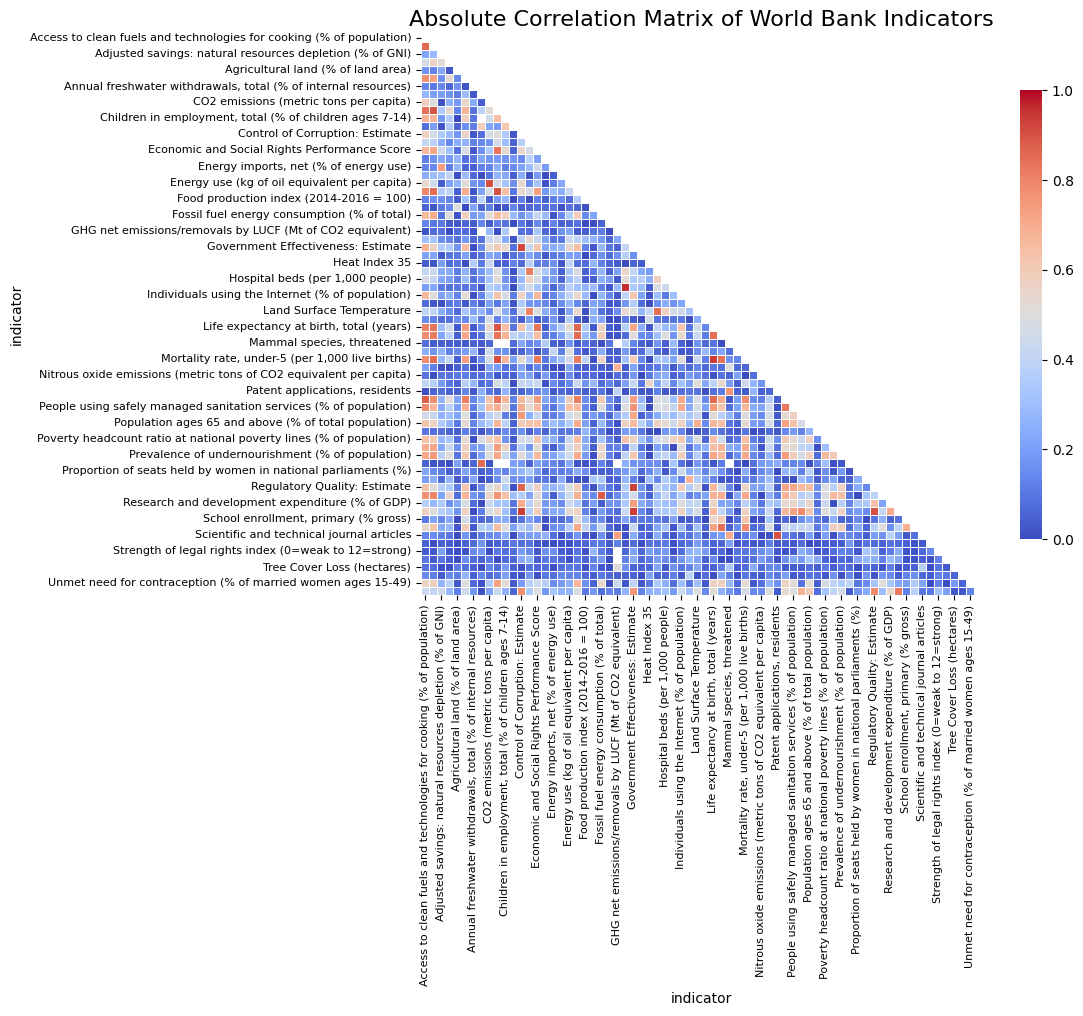

In [ ]:
# Set up the matplotlib figure size
plt.figure(figsize=(12, 10))

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap with the mask
sns.heatmap(
    corr_matrix,
    mask=mask,               # Hides upper half of the matrix
    cmap="coolwarm",         # Cool colors for low correlation, warm for high
    vmin=0, vmax=1,          # Corr range from 0 to 1 b/c .abs() applied
    annot=False,             # Don't show numbers
    square=True,             # Makes the grid cells square
    linewidths=.5,           # Adds thin lines between cells
    cbar_kws={"shrink": .8}  # Slightly shrinks the colorbar on the side
)

# Add titles and labels
plt.title("Absolute Correlation Matrix of World Bank Indicators", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# Display the plot
plt.show()

## Task 4: Data cleaning

In [ ]:
# Drop rows where the target variable is missing
df_wide = df_wide.dropna(subset=[target_col])

# Impute missing predictor values using column means
X = X.fillna(X.mean())

Re-running feature selection after cleaning

In [ ]:
# Compute correlation matrix of predictors
corr_matrix = X.corr().abs()

# Remove correlated predictors (corr > 0.9) to avoid multicollinearity
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]
X = X.drop(columns=to_drop)

# Check the number of features remaining
num_features_left = X.shape[1]
num_rows_left = X.shape[0]

print(f"Number of highly correlated features removed: {len(to_drop)}")
print(f"Number of features remaining: {num_features_left}")
print(f"Current dimensions of X (rows, columns): {X.shape}")

Number of highly correlated features removed: 0
Number of features remaining: 61
Current dimensions of X (rows, columns): (15296, 61)


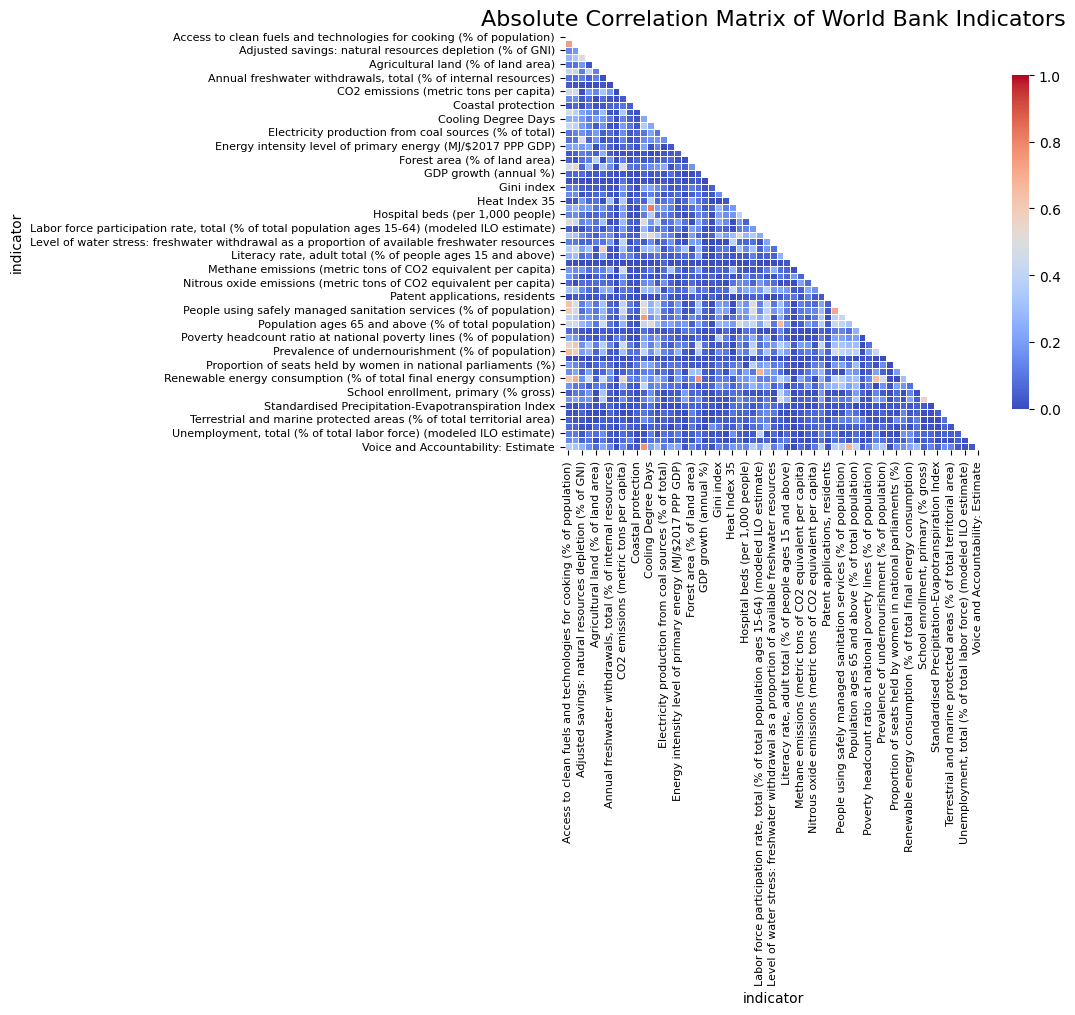

In [ ]:
# Set up the matplotlib figure size
plt.figure(figsize=(12, 10))

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap with the mask
sns.heatmap(
    corr_matrix,
    mask=mask,               # Hides upper half of the matrix
    cmap="coolwarm",         # Cool colors for low correlation, warm for high
    vmin=0, vmax=1,          # Corr range from 0 to 1 b/c .abs() applied
    annot=False,             # Don't show numbers
    square=True,             # Makes the grid cells square
    linewidths=.5,           # Adds thin lines between cells
    cbar_kws={"shrink": .8}  # Slightly shrinks the colorbar on the side
)

# Add titles and labels
plt.title("Absolute Correlation Matrix of World Bank Indicators", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Adjust layout so labels don't get cut off
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
#TASK 05

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- Re-execute necessary preceding steps to define df and df_wide ---
url = "https://github.com/masterfloss/data/raw/refs/heads/main/WBESG6123.xlsx"
df = pd.read_excel(url)

df = df.rename(columns={
    'REF_AREA_LABEL': 'country',
    'TIME_PERIOD': 'year',
    'INDICATOR_LABEL': 'indicator',
    'OBS_VALUE': 'value'
})
df = df[['country', 'year', 'indicator', 'value']]

df_wide = df.pivot_table(
    index=['country', 'year'],
    columns='indicator',
    values='value').reset_index()

target_col = "Renewable electricity output (% of total electricity output)"

# --- Data Cleaning (as in 9xhj4uEPzbBm) ---
# Drop rows where the target variable is missing
df_wide = df_wide.dropna(subset=[target_col])

# --- Re-extract X and y after df_wide cleaning ---
y = df_wide[target_col]
X = df_wide.drop(columns=['country', 'year', target_col])

# --- Feature Selection 1 (as in --Olg8c9uvsj) ---
corr_matrix_initial = X.corr().abs()
upper_triangle_initial = corr_matrix_initial.where(
    np.triu(np.ones(corr_matrix_initial.shape), k=1).astype(bool))
to_drop_initial = [
    column for column in upper_triangle_initial.columns if any(upper_triangle_initial[column] > 0.9)]
X = X.drop(columns=to_drop_initial)

# --- Impute missing predictor values (as in 9xhj4uEPzbBm) ---
X = X.fillna(X.mean())

# --- Feature Selection 2 (as in ZFbNT8Xq1MXP) ---
corr_matrix_final = X.corr().abs()
upper_triangle_final = corr_matrix_final.where(
    np.triu(np.ones(corr_matrix_final.shape), k=1).astype(bool))
to_drop_final = [
    column for column in upper_triangle_final.columns if any(upper_triangle_final[column] > 0.9)]
X = X.drop(columns=to_drop_final)

# --- Define DataSplitter class (from 9a373055) ---
class DataSplitter:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state

    def split_data(self):
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=self.test_size, random_state=self.random_state
        )
        return X_train, X_test, y_train, y_test

# --- Instantiate and split data ---
data_splitter = DataSplitter(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = data_splitter.split_data()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6341, 61)
Shape of X_test: (1586, 61)
Shape of y_train: (6341,)
Shape of y_test: (1586,)


In [ ]:
#TASk 06

In [ ]:
# Import necessary libraries for model training and evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Define the ModelTrainer class
class ModelTrainer:
    def __init__(self, regressor, X_train, y_train, X_test, y_test):
        # Store the initialized regressor model
        self.regressor = regressor
        # Store the training and testing data
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        # Initialize prediction and evaluation results
        self.y_pred = None
        self.r2 = None
        self.rmse = None
        self.mae = None

    def train_model(self):
        # Train the regressor using the training data
        print("Training model...")
        self.regressor.fit(self.X_train, self.y_train)
        print("Model training complete.")

    def predict(self):
        # Generate predictions on the test set
        print("Generating predictions...")
        self.y_pred = self.regressor.predict(self.X_test)
        print("Predictions generated.")

    def evaluate_model(self):
        # Calculate evaluation metrics: R-squared, RMSE, and MAE
        if self.y_pred is None:
            print("Predictions not generated yet. Please run predict() first.")
            return

        # R-squared (Coefficient of Determination)
        self.r2 = r2_score(self.y_test, self.y_pred)
        # Root Mean Squared Error (RMSE)
        self.rmse = np.sqrt(mean_squared_error(self.y_test, self.y_pred))
        # Mean Absolute Error (MAE)
        self.mae = mean_absolute_error(self.y_test, self.y_pred)

        print("Model Evaluation Metrics:")
        print(f"  R-squared: {self.r2:.4f}")
        print(f"  RMSE: {self.rmse:.4f}")
        print(f"  MAE: {self.mae:.4f}")

# Print a confirmation message that the class has been defined
print("ModelTrainer class defined successfully.")

ModelTrainer class defined successfully.


In [ ]:
# 1. Instantiate the regressor
# Initialize the RandomForestRegressor with a fixed random_state for reproducibility
# The number of estimators (n_estimators) is set to a common default, and random_state ensures consistent results.
regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Create an instance of ModelTrainer
# Pass the instantiated regressor and the split data to the ModelTrainer.
model_trainer = ModelTrainer(regressor, X_train, y_train, X_test, y_test)

# 3. Train the model
# Call the train_model method to fit the regressor to the training data.
model_trainer.train_model()

# 4. Generate predictions on the test set
# Call the predict method to get predictions for the test features.
model_trainer.predict()

# 5. Evaluate the model
# Call the evaluate_model method to calculate and print the R-squared, RMSE, and MAE.
model_trainer.evaluate_model()


Training model...
Model training complete.
Generating predictions...
Predictions generated.
Model Evaluation Metrics:
  R-squared: 0.9585
  RMSE: 5.9270
  MAE: 3.1171


## Task 07: Explain the Algorithm

A random forest is a meta-estimator that fits some decision tree regressors on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control overfitting. The key parameters of Random Forest include n_estimators (the number of trees in the forest), min_samples_split (the minimum number of samples required to split an internal node), max_depth (the maximum depth of the tree), and max_features (the number of features considered when looking for the best split).

Each tree is trained on a random bootstrap sample of the data (sampling with replacement). At each node of the tree, only a random subset of features is considered for splitting. After the trees are trained, each tree makes a prediction, and the final prediction for regression tasks is the average of all the individual tree predictions. This process is called bootstrap aggregation (bagging). Random Forest models are powerful because they can capture complex and non-linear relationships between variables without requiring strong assumptions about the data. However, they can be computationally expensive when using many trees and are generally less interpretable than simpler models such as linear regression.


##Task 08: OPP Refactor of the Full Pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

class RenewableEnergyModel:

    def __init__(self, url, target_col, test_size=0.2, random_state=42):
        self.url = url
        self.target_col = target_col
        self.test_size = test_size
        self.random_state = random_state

        self.df = None
        self.df_wide = None
        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.model = RandomForestRegressor(
            n_estimators=100,
            random_state=self.random_state
        )

        self.y_pred = None


    # 1. Load Data
    def load_data(self):
        print("Loading dataset...")
        self.df = pd.read_excel(self.url)


    # 2. Preprocess Data
    def preprocess_data(self):

        self.df = self.df.rename(columns={
            'REF_AREA_LABEL': 'country',
            'TIME_PERIOD': 'year',
            'INDICATOR_LABEL': 'indicator',
            'OBS_VALUE': 'value'
        })

        self.df = self.df[['country', 'year', 'indicator', 'value']]

        self.df_wide = self.df.pivot_table(
            index=['country', 'year'],
            columns='indicator',
            values='value'
        ).reset_index()

        # Drop missing target
        self.df_wide = self.df_wide.dropna(subset=[self.target_col])

        # Define X and y
        self.y = self.df_wide[self.target_col]
        self.X = self.df_wide.drop(columns=['country', 'year', self.target_col])


    # 3. Feature Selection
    def remove_correlated_features(self):

        corr_matrix = self.X.corr().abs()

        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        to_drop = [
            column for column in upper_triangle.columns
            if any(upper_triangle[column] > 0.9)
        ]

        self.X = self.X.drop(columns=to_drop)

        print(f"Removed {len(to_drop)} highly correlated features")


    # 4. Handle Missing Data
    def handle_missing(self):

        self.X = self.X.fillna(self.X.mean())


    # 5. Train/Test Split
    def split_data(self):

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=self.test_size,
            random_state=self.random_state
        )

        print("Data split complete.")
        print("Training set:", self.X_train.shape)
        print("Test set:", self.X_test.shape)


    # 6. Train Model
    def train_model(self):

        print("Training Random Forest model...")
        self.model.fit(self.X_train, self.y_train)


    # 7. Predict
    def predict(self):

        self.y_pred = self.model.predict(self.X_test)


    # 8. Evaluate Model
    def evaluate(self):

        r2 = r2_score(self.y_test, self.y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, self.y_pred))
        mae = mean_absolute_error(self.y_test, self.y_pred)

        print("\nModel Evaluation Metrics:")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")

In [ ]:
url = "https://github.com/masterfloss/data/raw/refs/heads/main/WBESG6123.xlsx"

target_col = "Renewable electricity output (% of total electricity output)"

model = RenewableEnergyModel(url, target_col)

model.load_data()
model.preprocess_data()
model.remove_correlated_features()
model.handle_missing()
model.split_data()
model.train_model()
model.predict()
model.evaluate()